
# FashionMNIST

![gif](assets/embedding.gif)


You should solve the FashionMNIST problems and be able to recognize clothes thanks to AI.

In [330]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import v2
import torch.nn.functional as F
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

In [303]:
# Transform each image into tensor
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True),])

# Set the training loader
train_data = datasets.FashionMNIST('../data', train=True, download=True, transform=transform)
# Set the testing loader
test_data = datasets.FashionMNIST('../data', train=False, download=True, transform=transform)

# The dataset

 - `train_data` is only for training your model.
 - `test_data`  is only for testing your model.

## Shape

```python
train_data = [
	[image], [label] # 1st example
	[image], [label] # 2nd example
	[image], [label] # 3rd example
	[image], [label] # 4th example
	... # 4th example
]
```

There's 60 000 examples in the train set, and 10 000 in the test set

### Image

An image is 28*28 in black & white

You can access the first image this way:

```python
image_0 = data[0][0]
```

### Label

A label is an integer between 0 and 9 (included)

You can access the first label this way:

```python
label_0 = data[0][0]
```

Here is the detail of each label

| Label | Description |
|:-|:-:|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |



In [304]:
print("Train len : " + str(len(test_data)))
print("Test len : " + str(len(train_data)))

Train len : 10000
Test len : 60000


In [305]:
print("Image Size: " + str(train_data[0][0].shape))

Image Size: torch.Size([1, 28, 28])


In [306]:
label_dic = {
	0 : "T-shirt/top",
	1 : "Trouser",
	2 : "Pullover",
	3 : "Dress",
	4 : "Coat",
	5 : "Sandal",
	6 : "Shirt",
	7 : "Sneaker",
	8 : "Bag",
	9 : "Ankle boot"
}

def plot_one_example(example):
	plt.imshow(example[0].view(28, 28), cmap="gray")
	plt.title("Label class {}: {}".format(example[1], label_dic[example[1]]))
	plt.show()

## Print some examples in train set
With plot one example, the firt and the last one in this case, we can see the the label associated and the image of it. 

With `print(train_data[n])`, we can see the tensor of the image, and in the end, the label associated.

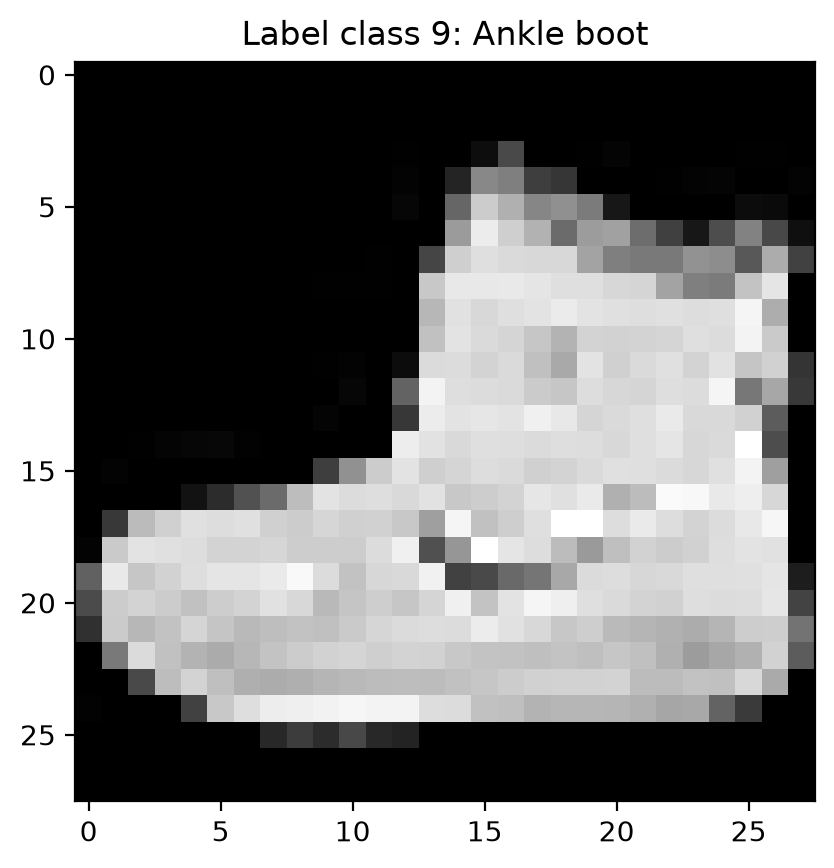

(Image([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510, 0.2863, 0.0000,
         0.0000, 0.0039, 0.0157, 0.0000, 0.0000, 0.000

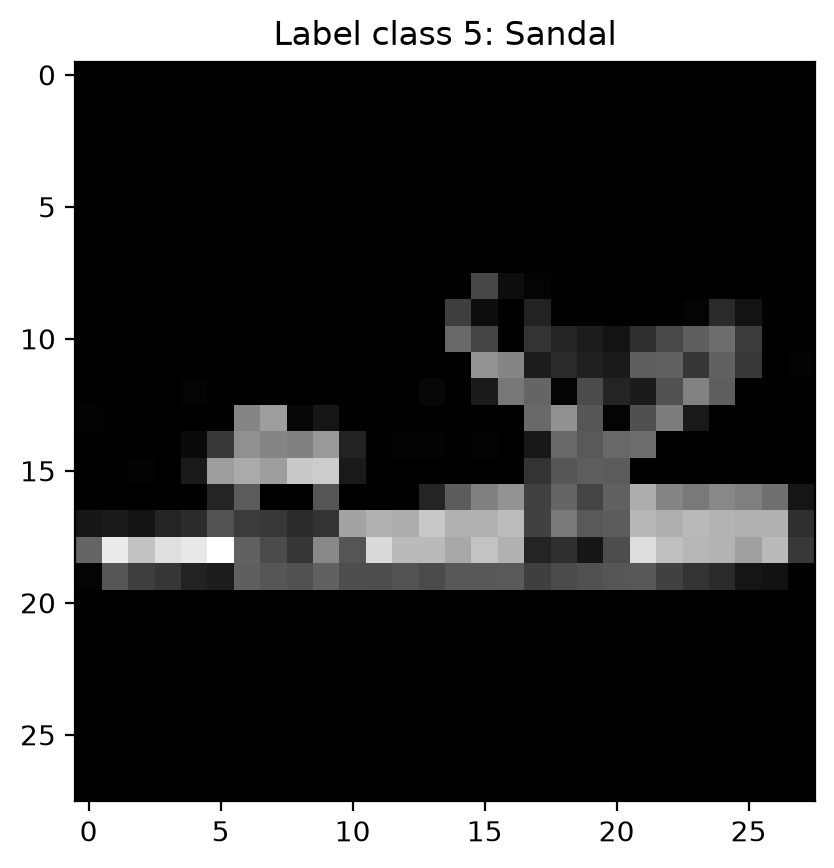

(Image([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.000

In [307]:
plot_one_example(train_data[0])
print(train_data[0])
plot_one_example(train_data[-1])
print(train_data[-1])

Time to train a model to predict the label of an image !

# 🚀 Good Luck

## First Thoughts

Before diving in, I expected some classes to be harder to classify than others.

Visually similar classes like T-shirt/Top (0), Pullover (2) and Shirt (6) are likely to be confused with each other, as well as the footwear categories: Sandal (5), Sneaker (7) and Ankle Boot (9).

Another interesting detail: all footwear images (Sandal, Sneaker, Ankle boot) are shown from a side/3-quarter angle, never from the front. And this will probably helps the model distinguish them from each other.

At first, I was thinking about using the faster model in this following [Zalando Benchmark](http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/) because I only have a CPU to run my model. the MLP was a good balance between performance and speed.

## Approach

I started simple: only a few layers, standard hyperparameters, and only 5 epochs to get a baseline.

From there, I refined iteratively and as long as both the train and test loss curves kept decreasing *together*, I kept tuning.

I did not log every single attempt and the final configuration reflects what worked best.

In [308]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')
print(device)

cpu


## Label distribution checking

We can se that the dataset is perfectly balanced with 6,000 samples per class, so we don't need to try rebalancing techniques such as oversampling or class weights.

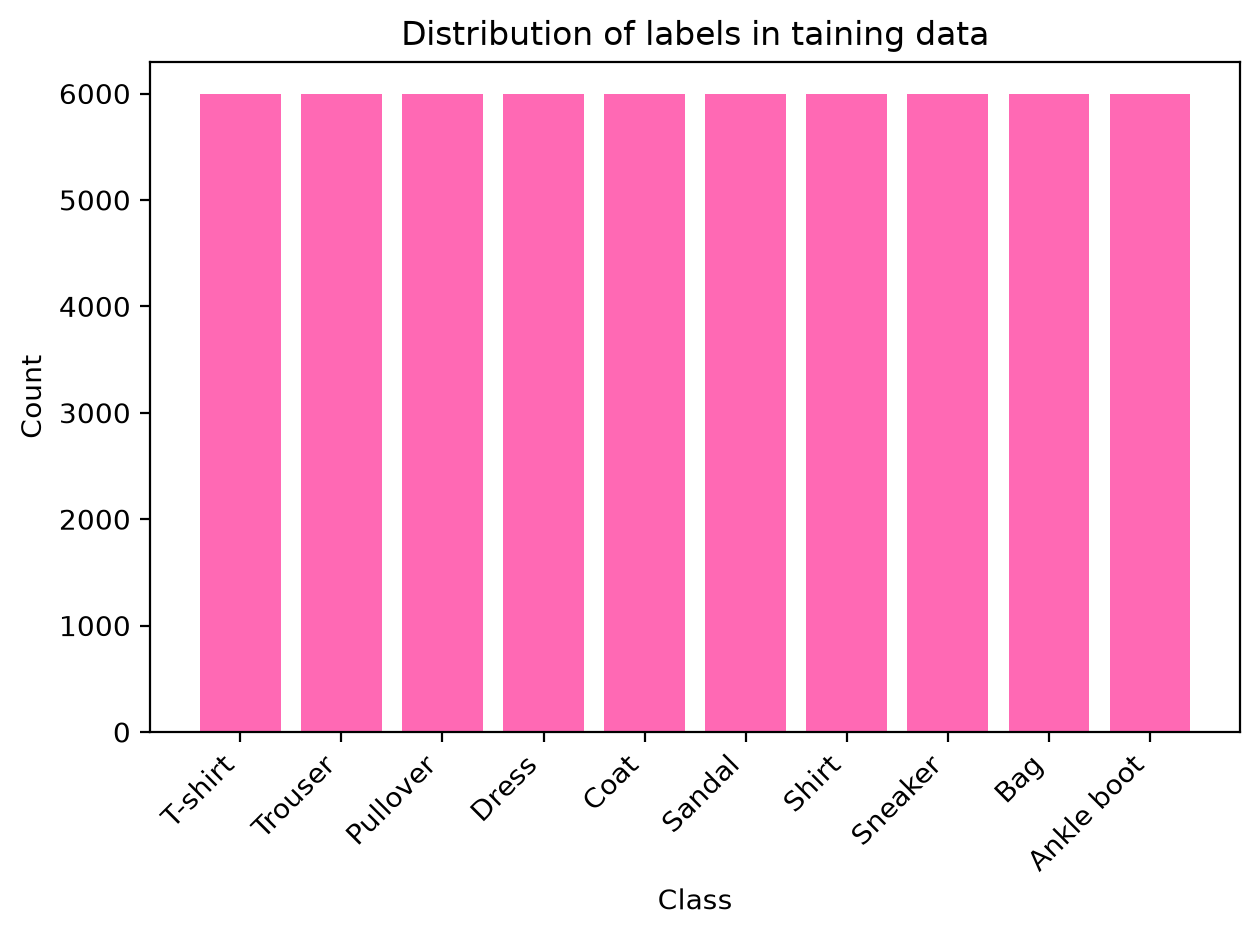

In [309]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

train_labels = [label for _, label in train_data]
train_labels_count = np.bincount(train_labels)

plt.bar(class_names, train_labels_count, color="hotpink")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribution of labels in taining data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Designing the model
We have 784 numbers (28 x 28 pixels size for the input) that are used to reprents our model, so the input layer will be 784.

The hidden layers will be 512. I can choose the number of hidden layers and the size, so more tests are needed!

We need 10 neurons to reprents the output (because there is 10 labels).

In [310]:
trainloader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=True)

I fixed a random seed (as 42) to guarantee that the outcome will be the same everytime I run my code.

In [311]:
torch.manual_seed(42)
np.random.seed(42)

## Create the architecture → MLP (Multi-Layer Perceptron)

I chose a MLP as it is the simplest neural network architecture suited for this task.

Since Fashion-MNIST images are 28x28 grayscale, they are flattened into a 784-dimensional vector and passed through 3 hidden layers (256 → 128 → 64) before the output layer (10 classes).

In [312]:
# c'est un MLP (Multi Layer Perceptron) avec 3 couches cachées et une 
# fonction d'activation ReLU. La dernière couche utilise la fonction 
# log_softmax pour produire des probabilités log-linéaires pour chaque classe.
class MLP(nn.Module):
	def __init__(self):
		super().__init__()
		self.fc1 = nn.Linear(784, 256) 
		self.fc2 = nn.Linear(256, 128) 
		self.fc3 = nn.Linear(128, 64) 
		self.fc4 = nn.Linear(64, 10) 
		
	def forward(self, x):
		x = x.view(x.shape[0], -1)
		
		x = F.relu(self.fc1(x))
		x = F.relu(self.fc2(x))
		x = F.relu(self.fc3(x))
		
		# softmax avec nn.NLLLoss() a enlever pour utiliser avec nn.CrossEntropyLoss() qui combine log_softmax et NLLLoss
		x = F.log_softmax(self.fc4(x), dim = 1)
		#x = self.fc4(x)
		
		return x

model = MLP()

In [313]:
#Defining the criterion (loss function) and optimizer

criterion =  nn.NLLLoss()
#criterion = nn.CrossEntropyLoss() # alternative to NLLLoss() with log_softmax in the model

optimizer = optim.Adam(model.parameters(), lr = 0.001)
#optimizer = optim.SGD(model.parameters(), lr = 0.005, momentum=0.9)

# Let's start training !! 🚀

I plotted both the train and test loss curves to make sure the model is not overfitting.

If the two curves follow the same trend, the model is generalizing well to unseen data.

If both curves decrease together, then the model is learning well!

In [314]:
epochs = 8
train_losses = []
test_losses = []

for e in range(epochs):
	train_loss = 0
	model.train()
	for images, labels in trainloader:
		images = images.view(images.shape[0], -1)
		
		optimizer.zero_grad()
		logps = model(images)
		loss = criterion(logps, labels)
		loss.backward()
		optimizer.step()
		
		train_loss += loss.item()
	
	test_loss = 0
	model.eval()
	with torch.no_grad():
		for images, labels in testloader:
			images = images.view(images.shape[0], -1)

			logps = model(images)
			loss = criterion(logps, labels)

			test_loss += loss.item()
		
	train_losses.append(train_loss / len(trainloader))
	test_losses.append(test_loss / len(testloader))
	print(f"Epoch {e + 1}/{epochs}\n Train loss: {train_losses[-1]:.4f} // Test loss: {test_losses[-1]:.4f}")

Epoch 1/8
 Train loss: 0.5579 // Test loss: 0.4506
Epoch 2/8
 Train loss: 0.3777 // Test loss: 0.3897
Epoch 3/8
 Train loss: 0.3373 // Test loss: 0.3752
Epoch 4/8
 Train loss: 0.3132 // Test loss: 0.3686
Epoch 5/8
 Train loss: 0.2933 // Test loss: 0.3447
Epoch 6/8
 Train loss: 0.2795 // Test loss: 0.3401
Epoch 7/8
 Train loss: 0.2662 // Test loss: 0.3424
Epoch 8/8
 Train loss: 0.2540 // Test loss: 0.3260


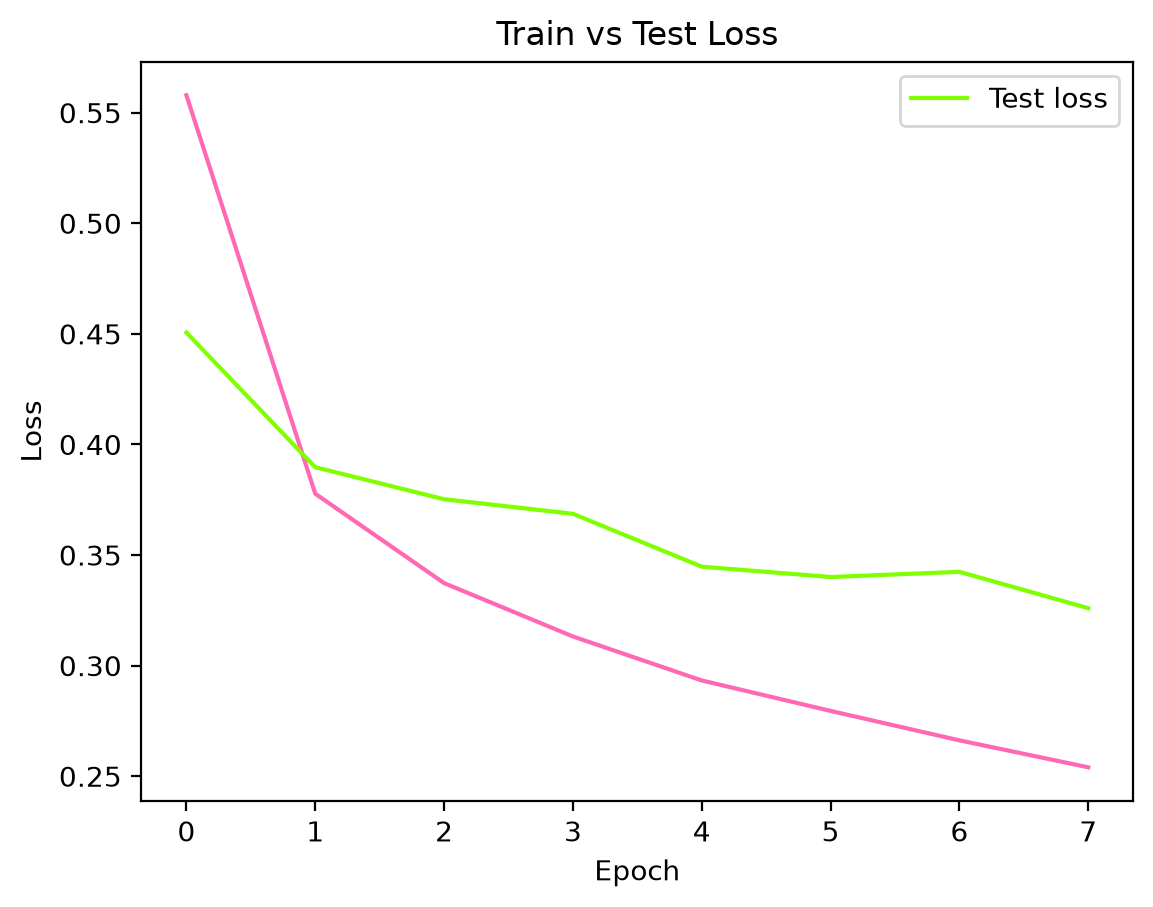

In [315]:
plt.plot(train_losses, color="hotpink")
plt.plot(test_losses, color="chartreuse", label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss")
plt.legend()
plt.show()

# Time for some evaluation 📝
I used the following metrics:
- **Accuracy**: the percentage of correctly classified images over the entire test set
- **Classification Report**: precision, recall and F1-score per class, which gives a more detailed view than accuracy alone
- **Confusion Matrix**: shows which classes are most confused with each other 

In [316]:
correct = 0
total = 0
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.view(images.shape[0], -1)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(classification_report(all_labels, all_preds, target_names=class_names))

Accuracy: 0.8854
              precision    recall  f1-score   support

     T-shirt       0.82      0.87      0.85      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.81      0.80      0.80      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.73      0.66      0.69      1000
     Sneaker       0.94      0.95      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.88      0.89      0.88     10000
weighted avg       0.88      0.89      0.88     10000



### Confusion Matrix & Classification Report Analysis

The model achieved an overall accuracy of **88.54%**.

Strongest classes:
- **Trouser** (F1: 0.98) and **Bag** (F1: 0.97) are almost perfectly classified
- **Sandal**, **Sneaker** and **Ankle boot** all perform well (F1: 0.94-0.96)

Weakest class:
- **Shirt** is by far the hardest class (F1: 0.69), heavily confused with T-shirt (139 misclassifications) and Pullover (82)
- **Pullover** and **Coat** also confuse each other (93 and 59 misclassifications respectively)

These results confirm my initial hypothesis!

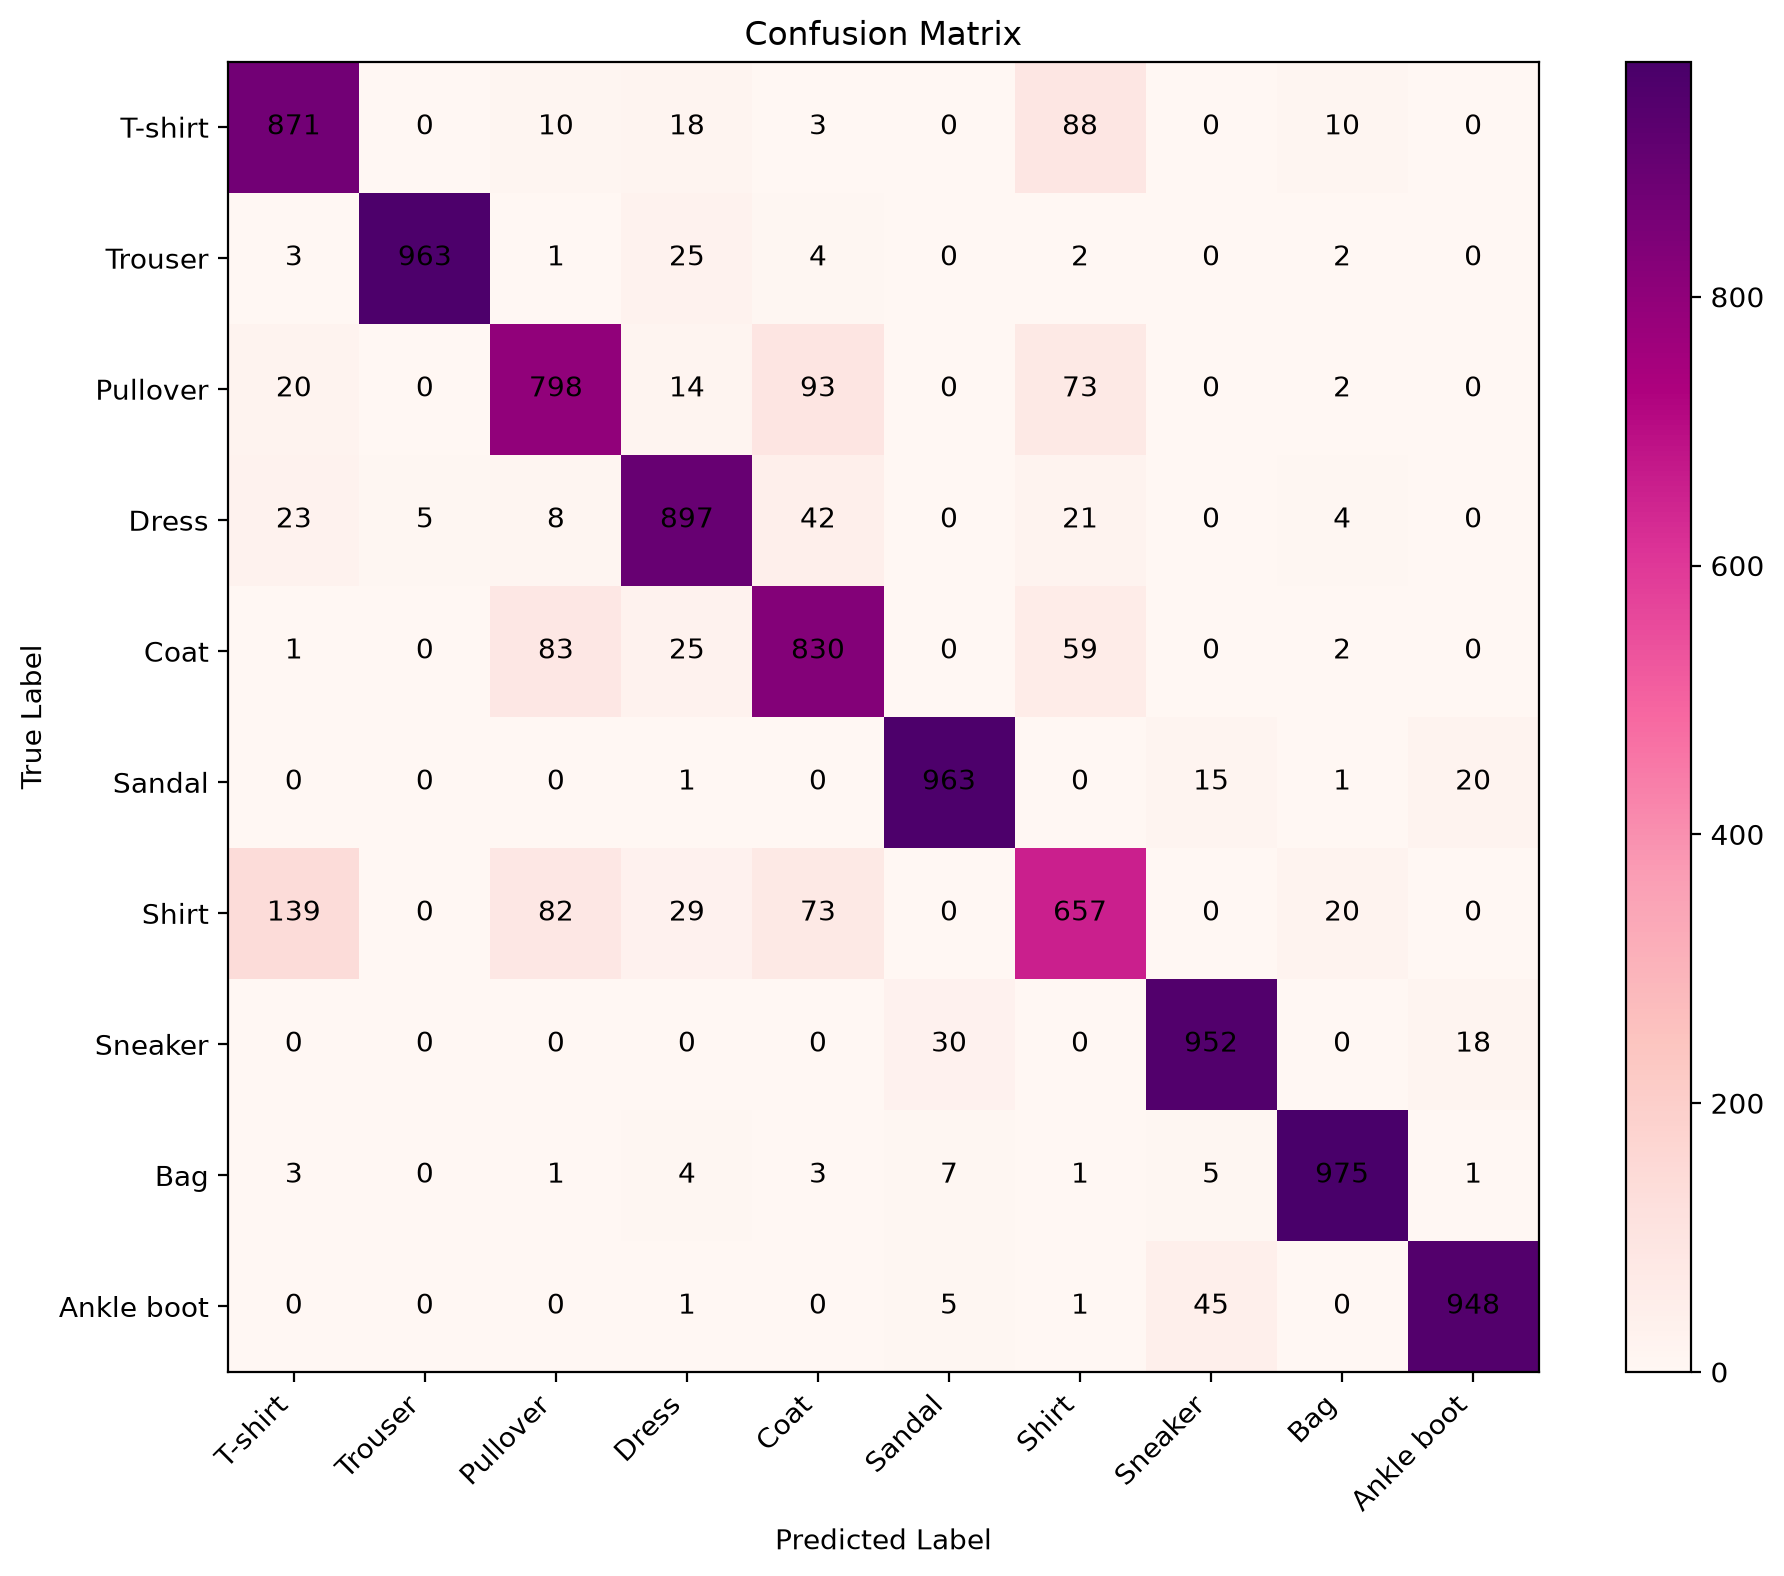

In [317]:
matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
plt.imshow(matrix, cmap="RdPu")
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(matrix[i, j]), ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

## Let's see !
We can now see each image and the probabilities by modifying both indexes in `images[n]`.

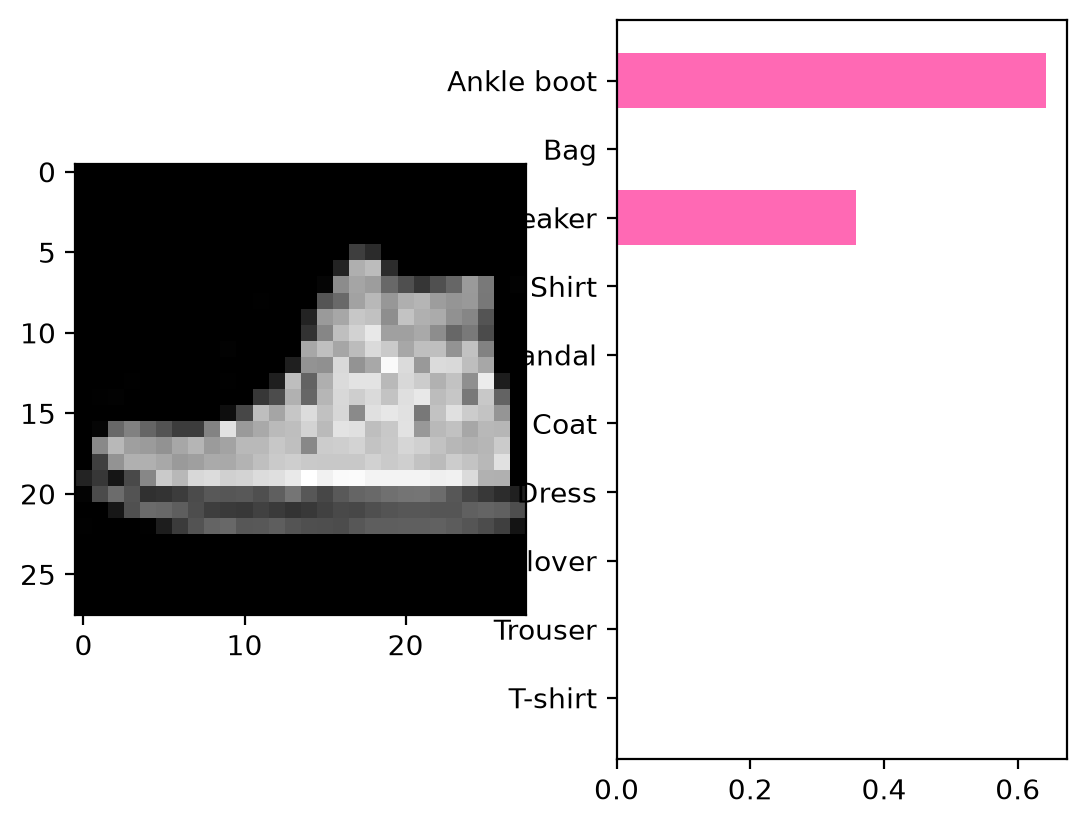

In [319]:
img = images[5].squeeze().view(28, 28)
prob = torch.exp(model(images[5].view(1, 784)))

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(img, cmap="gray")
ax2.barh(range(10), prob.detach().numpy()[0], color="hotpink")
ax2.set_yticks(range(10))
ax2.set_yticklabels(["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"])
plt.show()

*changes that I made for each runing are in italics*
### MLP v1

| Parameters | Value |
|------------|---------|
| Architecture | [256, 128, 64] |
| Activation Function | ReLU |
| Loss Function | NLLLoss |
| Optimizer | Adam |
| Learning Rate | 0.005 |
| Batch Size | 64 |
| Epochs | 5 |
| Training Time | 00:02:38 |
| Accuracy | **85.80 %** |

### MLP v2

| Parameters | Value |
|------------|---------|
| Architecture | [256, 128, 64] |
| Activation Function | ReLU |
| *Loss Function* | *CrossEntropyLoss* |
| Optimiseur | Adam |
| Learning Rate | 0.005 |
| Batch Size | 64 |
| Epochs | 5 |
| Training Time | 00:02:36 |
| Accuracy | **87.06 %** |

### MLP v3

| Parameters | Value |
|------------|---------|
| Architecture | [256, 128, 64] |
| Activation Function | ReLU |
| Loss Function | NLLLoss |
| *Optimiseur* | *SGD* |
| Learning Rate | 0.005 |
| *Momentum* | *0.9* |
| Batch Size | 64 |
| Epochs | 5 |
| Training Time | 00:02:35 |
| Accuracy | **85,67 %** |

### MLP v4

| Parameters | Value |
|------------|---------|
| Architecture | [256, 128, 64] |
| Activation Function | ReLU |
| Loss Function | NLLLoss |
| Optimiseur | Adam |
| *Learning Rate* | *0.001* |
| Batch Size | 64 |
| Epochs | 5 |
| Training Time | 00:02:41 |
| Accuracy | **87.67%** |

### MLP v4

| Parameters | Value |
|------------|---------|
| Architecture | [256, 128, 64] |
| Activation Function | ReLU |
| Loss Function | NLLLoss |
| Optimiseur | Adam |
| Learning Rate | 0.001 |
| Batch Size | 64 |
| *Epochs* | *10* |
| Training Time | 00:05:23 |
| Accuracy | **88.82%** |


---

### FINAL VERSION !
| Parameters | Value |
|------------|---------|
| Architecture | [256, 128, 64] |
| Activation Function | ReLU |
| Loss Function | NLLLoss |
| Optimiseur | Adam |
| Learning Rate | 0.001 |
| Batch Size | 64 |
| Epochs | 8 |
| Training Time | 00:04:30 |
| Accuracy | **88.54%** |

## Let's try with customs images !!
To go further, I wanted to try the model on a custom image. I searched for "pixel art [dress/bag]" on google and found some interesting images to test. I also took a picture of my own sandal to test, even if I knew it will be very difficult to the model.

All images are preprocessed the same way as the training data: converted to grayscale and resized to 28x28.

This is a fun way to see how the model generalizes to real-world inputs!

### Results - Observations
- bag.jpg: predicted bag
- dress.jpg: predicted bag
- heels.png: predicted bag
- real_heels.png: predicted bag

When testing the model on custom images, all predictions came out as **Bag (8)**.

As we can see in the confusion matrix, Bag is one of the best performing classes with 975 correct predictions and very few false positives from other classes. So we can think that the model is strongly biased towards predicting Bag when it is uncertain.


Predicted: Bag


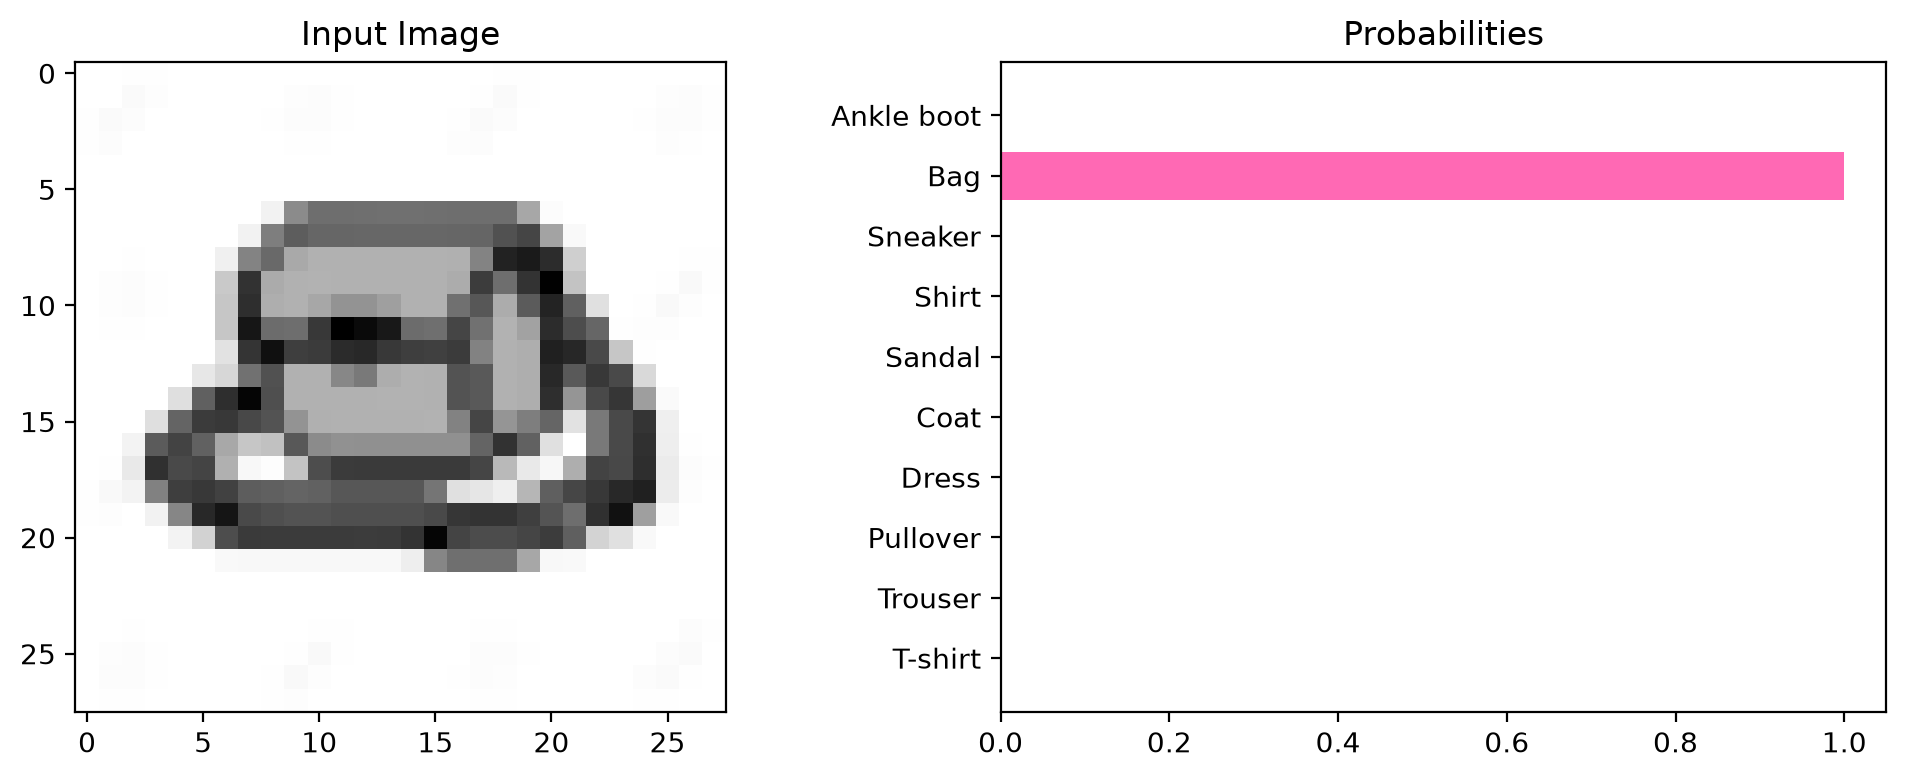

In [ ]:
img = Image.open("assets/bag.jpg")  

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

img_tensor = transform(img).view(1, 784)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    prob = torch.exp(output)
    _, predicted = torch.max(output, 1)

print(f"Predicted: {class_names[predicted.item()]}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(img_tensor.view(28, 28), cmap="gray")
ax1.set_title("Input Image")
ax2.barh(class_names, prob.numpy()[0], color="hotpink")
ax2.set_title("Probabilities")
plt.tight_layout()
plt.show()

# Conclusion
## Limitations

- **Background mismatch**: Fashion-MNIST uses black background + white object and real images are the opposite
- **Shirt is hard**: even for humans, Shirt vs T-shirt vs Pullover is tricky and the model struggles too (F1: 0.69)
- **No data augmentation**: the model only saw clean, centered images during training, so it's not great with anything outside that distribution
- **CPU only**: limited how many experiments I could run in 48h

## What I Would Have Done With More Time

- **CNN**: a convolutional neural network would likely perform better than the MLP, as it can detect spatial patterns like edges and textures. much more suited for image classification!
- **Grid search**: I would have liked to systematically tune hyperparameters (learning rate, batch size, number of layers) instead of testing manually
- **Data augmentation**: adding random flips or rotations during training to make the model more robust to real-world images
- **Early stopping**: automatically stop training when the test loss stops improving instead of picking epochs manually

## Resources
### Docs
- https://docs.pytorch.org/docs/2.12/generated/torch.nn.Module.html 
- https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html 
- https://matplotlib.org/stable/tutorials/pyplot.html 
- https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.barh.html
- https://pillow.readthedocs.io/en/stable/handbook/tutorial.html
- https://docs.pytorch.org/vision/stable/transforms.html

### Dataset Description
- https://github.com/zalandoresearch/fashion-mnist 
- https://www.kaggle.com/datasets/zalando-research/fashionmnist
- https://fr.wikipedia.org/wiki/Fashion_MNIST  
- http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/ 

### YouTube Videos
- https://www.youtube.com/watch?v=qMhEBPCQVUM&t=657s 
- https://www.youtube.com/watch?v=EJcvY9BDIa8

### Tutorials
- https://medium.com/@smrati.katiyar/fashion-mnist-image-classification-using-pytorch-54444a134990 
-  https://medium.com/analytics-vidhya/image-classification-with-fashion-mnist-dataset-and-pytorch-719a305d7374 
- https://medium.com/analytics-vidhya/activation-functions-optimization-techniques-and-loss-functions-75a0eea0bc31 
- https://github.com/Afaf-Athar/Fashion-MNIST-Classification-DL/blob/master/Fashion-%20MNIST.ipynb 
- https://karpathy.github.io/2019/04/25/recipe/ 
- https://people.minesparis.psl.eu/fabien.moutarde/ES_MachineLearning/Practical_MLP-neuralnetworks/mlp-notebook.html 
